# RL-QAS: <ins>R</ins>einforcement <ins>L</ins>earning for <ins>Q</ins>uantum <ins>A</ins>rchitecture <ins>S</ins>earch

<p align="center">
  <img src="pics/intro.png" alt="title">
</p>

## Importing the dependencies

### Import quantum simulator

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity

### Importing modules to train neural network

In [4]:
import torch
import torch.nn as nn
import random
import copy
from collections import namedtuple
import numpy as np
from itertools import product
import time

----------------------
# RL: <ins>R</ins>einforcement <ins>L</ins>earning
## The framework

<p align="center">
  <img src="pics/RL.png" alt="title">
</p>

----------------------
# RL-QAS: <ins>R</ins>einforcement <ins>L</ins>earning for <ins>Q</ins>uantum <ins>A</ins>rchitecture <ins>S</ins>earch
## The framework

<p align="center">
  <img src="pics/RL_QAS.png" alt="title">
</p>

## Action space preparation

**Action space** $\rightarrow$ **Quantum gates**. We consider the universal gateset:

- 1-qubit gates: $\texttt{RX}$, $\texttt{RY}$, $\texttt{RZ}$,
- 2-qubit gates: $\texttt{CNOT}$

The **action space** is represented by a *dictionary* where each *key* in the dictionary is a quantum gate represented as:

$\begin{equation} \textrm{action space dict} = \{0:[\underbrace{0,1}_{\text{position of 2-qubit gate}},\underbrace{N,0}_{\text{position of 1-qubit gate}}], 1: [N,0, 0,0], ...\} \end{equation}$

### Disecting an action
The 0th key action defines: $[\underbrace{0}_{\text{position of control}}, \underbrace{1}_{\text{position of target}}, \underbrace{N}_{\text{1-qubit rotation position}}, \underbrace{0}_{\text{1-qubit rotation direction}}]$

- Hence the 0-th key: $[0, 1, N, 0]$ defines a $\texttt{CNOT}$ gate with control at 0th qubit and target at 1st qubit. The 3rd and 4th terms are place holders and having an $N$ at 3rd position means it is not a 1-qubit gate. So each action is basicallt one gate
- The 1st key: $[N,0, 0,0]$, having an $N$ in the control position defines that it is not representing a 2-qubit gate. And then we have 3rd element says we have 1-qubit gate on 1st qubit and the 4th element says we have a $\texttt{X}$ gate.

<p align="center">
  <img src="pics/action_space_mod.png" alt="title">
</p>

In [5]:
def dictionary_of_actions(num_qubits):
    """
    Creates dictionary of actions for system which steers positions of gates,
    and axes of rotations.
    """
    dictionary = dict()
    i = 0
         
    for c, x in product(range(num_qubits), range(num_qubits)):
        if c != x:
            dictionary[i] = [c, x, num_qubits, 0]
            i += 1
   
    """h  denotes 1q gate. 0, 1, 2, 3 -->  X, Y, Z, H gate """
    for r, h in product(range(num_qubits),
                           range(0, 4)):
        dictionary[i] = [num_qubits, 0, r, h]
        i += 1
    return dictionary

## Here is how the dictionary of the actions looks like

In [6]:
dictionary_of_actions(2)

{0: [0, 1, 2, 0],
 1: [1, 0, 2, 0],
 2: [2, 0, 0, 0],
 3: [2, 0, 0, 1],
 4: [2, 0, 0, 2],
 5: [2, 0, 0, 3],
 6: [2, 0, 1, 0],
 7: [2, 0, 1, 1],
 8: [2, 0, 1, 2],
 9: [2, 0, 1, 3]}

### Action space design:

> Can you edit the dictionary of actions to remove the Y and Z gates and construct a new function called "dictionary_of_actions_h_x_cx"? 

> After successfully completing first steps:

- Train and compare agent with action space *(a1)* "X, Y, Z, H, CX" *(a2)* "X, H, CX"

> Investigate weather with *(a1)* an agent consumes more/less training time and *(a2)*

**Solution:**

In [7]:
def dictionary_of_actions_h_x_cx(num_qubits):
    """
    Creates dictionary of actions for system which steers positions of gates,
    and axes of rotations.
    """
    dictionary = dict()
    i = 0
         
    for c, x in product(range(num_qubits), range(num_qubits)):
        if c != x:
            dictionary[i] = [c, x, num_qubits, 0]
            i += 1
   
    """h  denotes 1q gate. 0, 1 -->  X, H gate """
    for r, h in product(range(num_qubits),
                           range(0, 2)):
        dictionary[i] = [num_qubits, 0, r, h]
        i += 1
    return dictionary

In [8]:
dictionary_of_actions_h_x_cx(2)

{0: [0, 1, 2, 0],
 1: [1, 0, 2, 0],
 2: [2, 0, 0, 0],
 3: [2, 0, 0, 1],
 4: [2, 0, 1, 0],
 5: [2, 0, 1, 1]}

In [14]:
class RLQAS_Env:
    """
    Minimal environment for RL-QAS on 2-qubit Bell state |Phi+> = (|00>+|11>)/sqrt(2).

    State encoding:
      state.shape = (num_layers, num_qubits+4, num_qubits)
      - rows 0..num_qubits-1: CNOT occupation (targ, ctrl)
      - rows num_qubits..num_qubits+4: one-qubit gates [X, Y, Z, H] on each qubit
    """

    def __init__(self,
                 num_qubits=2,
                 num_layers=4,
                 fidelity_reward_scale=50.0,
                 done_threshold=0.99,
                 modified_action = 0,
                 device="cpu"):

        self.num_qubits = num_qubits
        self.num_layers = num_layers
        self.device = torch.device(device)
        self.fidelity_reward_scale = fidelity_reward_scale
        self.done_threshold = done_threshold
        self.modified_action = modified_action

        # Action/state sizes useful for the agent
        if self.modified_action:
            self.state_size = self.num_layers * self.num_qubits * (self.num_qubits + 2)
        else:
            self.state_size = self.num_layers * self.num_qubits * (self.num_qubits + 4)
        if modified_action:
            self.action_size = len(dictionary_of_actions_h_x_cx(num_qubits=num_qubits).keys())
        else:
            self.action_size = len(dictionary_of_actions(num_qubits=num_qubits).keys())


        print(self.action_size)
        # exit()

        # Initial density matrix |00>
        if self.num_qubits == 2:
            self.init_state = DensityMatrix(np.array([
                [1, 0, 0, 0],
                [0, 0, 0, 0],
                [0, 0, 0, 0],
                [0, 0, 0, 0]
            ]))
            bell_state = (1/np.sqrt(2)) * np.array([1, 0, 0, 1])
            self.target_state = DensityMatrix(np.outer(bell_state, bell_state.conj()))
        elif self.num_qubits == 3:
            self.init_state = DensityMatrix(np.array([
                [1, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
            ]))
        
            # Target GHZ state: (|000> + |111>) / sqrt(2)
            ghz_state = (1 / np.sqrt(2)) * np.array([
                1, 0, 0, 0, 0, 0, 0, 1
            ])
        
            self.target_state = DensityMatrix(
                np.outer(ghz_state, ghz_state.conj())
            )
        else:
            raise ValueError("This minimal example is intended for 3 qubits.")

        # Target Bell state |Phi+>
        

        # Qiskit simulator
        self.sim = AerSimulator(method="statevector")

        # Internal env variables set in reset()
        self.state = None
        self.moments = None
        self.step_counter = None
        self.error = None
        self.prev_cost = None

    # -------- Gym-like API --------
    def reset(self):
        """
        Initialize empty circuit representation and internal counters.
        Returns flattened state tensor on the chosen device.
        """
        # RL state: (layers, cnot+x+y+z+h, qubits)
        if self.modified_action:
            self.state = torch.zeros(
                (self.num_layers, self.num_qubits + 2, self.num_qubits),
                dtype=torch.float32
            )
        else:
            self.state = torch.zeros(
                (self.num_layers, self.num_qubits + 4, self.num_qubits),
                dtype=torch.float32
            )

        # one "moment" counter per qubit: how many gates placed on that worldline
        self.moments = [0] * self.num_qubits

        # no gates yet
        self.step_counter = -1

        # initial cost
        self.prev_cost = self._compute_fidelity()
        self.error = float(abs(self.prev_cost))

        return self.state.reshape(-1).to(self.device)

    def step(self, action, train_flag=True):
        """
        Apply one action to the circuit representation.

        action: list or tensor of length 4: [ctrl, targ_offset, rot_qubit, rot_axis]
        Returns: next_state_flat, reward (torch scalar), done (bool)
        """
        if isinstance(action, torch.Tensor):
            action = action.tolist()

        ctrl = int(action[0])
        targ = int(action[1])
        rot_qubit = int(action[2])
        rot_axis = int(action[3])

        next_state = self.state.clone()
        self.step_counter += 1

        # decide in which "time slot" (moment) to place the gate(s)
        # if rot_qubit < num_qubits, use that qubit's moment,
        # else if ctrl < num_qubits, use max moment of ctrl and targ
        if rot_qubit < self.num_qubits:
            gate_layer = self.moments[rot_qubit]
        elif ctrl < self.num_qubits:
            gate_layer = max(self.moments[ctrl], self.moments[targ])
        else:
            gate_layer = 0  # no-op action; you could also treat this differently

        # Place CNOT if ctrl < num_qubits
        if ctrl < self.num_qubits:
            next_state[gate_layer][targ][ctrl] = 1.0
        if rot_qubit < self.num_qubits:
            oneq_row = self.num_qubits + rot_axis
            next_state[gate_layer][oneq_row][rot_qubit] = 1.0

        # Update moments
        if rot_qubit < self.num_qubits:
            self.moments[rot_qubit] += 1
        elif ctrl < self.num_qubits:
            max_m = max(self.moments[ctrl], self.moments[targ])
            self.moments[ctrl] = max_m + 1
            self.moments[targ] = max_m + 1

        # Update internal state
        self.state = next_state.clone()

        # Compute fidelity and reward
        fidelity = self._compute_fidelity()
        self.error = float(fidelity)  # error = 1 - fidelity

        reward = self._reward_from_fidelity(fidelity)
        self.prev_cost = fidelity

        # Episode termination:
        #   - success if fidelity >= done_threshold
        #   - or if we used all layers
        done_success = fidelity >= self.done_threshold
        done_layers = (self.step_counter >= self.num_layers - 1)
        done = bool(done_success or done_layers)

        next_state_flat = self.state.reshape(-1).to(self.device)
        reward_torch = torch.tensor(reward, dtype=torch.float32, device=self.device)

        return next_state_flat, reward_torch, done

    """
    In _make_circuit() function: 
        We reconstruct the quantum circuits from the "RL-state"
    """
    def _make_circuit(self):
        """
        Convert the discrete state tensor into a concrete QuantumCircuit.
        """
        circ = QuantumCircuit(self.num_qubits)

        state_np = self.state.numpy()
        for layer in range(self.num_layers):
            # CNOTs: rows 0..num_qubits-1 (targ index = row, ctrl index = col)
            cnot_block = state_np[layer, 0:self.num_qubits, :]
            targ_idx, ctrl_idx = np.where(cnot_block == 1.0)
            for t, c in zip(targ_idx, ctrl_idx):
                circ.cx(c, t)
        
            # One-qubit gates: X,Y,Z in rows num_qubits+0,1,2
            if self.modified_action:
                oneq_block = state_np[layer, self.num_qubits:self.num_qubits+ 2, :]
                gate_rows, qubits = np.where(oneq_block == 1.0)
                for g_row, q in zip(gate_rows, qubits):
                    if g_row == 0:
                        circ.x(int(q))
                    elif g_row == 1:
                        circ.h(int(q))
                

            else:
                oneq_block = state_np[layer, self.num_qubits:self.num_qubits+ 4, :]
                gate_rows, qubits = np.where(oneq_block == 1.0)
                for g_row, q in zip(gate_rows, qubits):
                    if g_row == 0:
                        circ.x(int(q))
                    elif g_row == 1:
                        circ.y(int(q))
                    elif g_row == 2:
                        circ.z(int(q))
                    elif g_row == 3:
                        circ.h(int(q))

        return circ

    def _compute_fidelity(self):
        """
        Compute fidelity F(rho, target) between evolved state and Bell state.
        """
        circ = self._make_circuit()
        print(circ)
        # start from |00>, evolve with circ
        rho_evolved = self.init_state.evolve(circ)
        fid = state_fidelity(rho_evolved, self.target_state)
        return float(fid)
    
    def _reward_from_fidelity(self, x=None):
        scalar = 50
        if self.error >= self.done_threshold:
            rwd = scalar*self.error
        else:
            rwd = self.error
        return rwd

In [ ]:
num_qubits, max_steps, num_episodes = 2, 6, 1000

import torch.optim as optim

modified_action = 0
if modified_action:
    actions_dict = dictionary_of_actions_h_x_cx(num_qubits=num_qubits)
else:
    actions_dict = dictionary_of_actions(num_qubits=num_qubits)

num_actions = len(actions_dict)
device = torch.device("cpu")

# --- instantiate environment ---
env = RLQAS_Env(num_qubits=num_qubits, num_layers=max_steps, device=device, fidelity_reward_scale=50, modified_action=modified_action)


state_dim = env.state_size  # flattened state length
action_dim = num_actions    # discrete actions 0..9

# --- tiny DQN network ---
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)

q_net = DQN(state_dim, action_dim).to(device)
target_net = DQN(state_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# --- simple replay buffer ---
replay_buffer = []
buffer_capacity = 5000
batch_size = 32
gamma = 0.99

def push_transition(transition):
    if len(replay_buffer) >= buffer_capacity:
        replay_buffer.pop(0)
    replay_buffer.append(transition)

def sample_batch():
    batch = random.sample(replay_buffer, batch_size)
    state_b, action_b, reward_b, next_state_b, done_b = zip(*batch)
    state_b = torch.stack(state_b)
    action_b = torch.tensor(action_b, dtype=torch.long, device=device)
    reward_b = torch.tensor(reward_b, dtype=torch.float32, device=device)
    next_state_b = torch.stack(next_state_b)
    done_b = torch.tensor(done_b, dtype=torch.float32, device=device)
    return state_b, action_b, reward_b, next_state_b, done_b

# --- epsilon-greedy parameters ---
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 1000   # in steps
global_step = 0

def get_epsilon(step):
    return max(epsilon_end, epsilon_start - step / epsilon_decay)

def select_action(state_vec):
    global global_step
    epsilon = get_epsilon(global_step)
    global_step += 1
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)
    with torch.no_grad():
        q_values = q_net(state_vec.unsqueeze(0))
        return int(q_values.argmax(dim=1).item())

# --- training loop ---
max_steps_per_episode = max_steps
target_update_freq = 20  # episodes

episode_rewards_wo_mod_action = []
episode_final_fidelities_wo_mod_action = []
episode_final_epsilons_wo_mod_action = []
episode_num_gates_wo_mod_action = []  # total gates used in that episode
episode_time_wo_mod_action = []  # total time spend in that episode

for ep in range(num_episodes):
    state = env.reset()                         # shape: [state_dim], already on device
    state = state.to(device)
    total_reward = 0.0
    total_gates = 0
    total_time = 0

    for t in range(max_steps_per_episode):
        t1 = time.time()
        
        # choose action index via epsilon-greedy
        a_idx = select_action(state)
        action = actions_dict[a_idx]
        print(action)

        # step environment
        next_state, reward_t, done = env.step(action)
        next_state = next_state.to(device)

        r = reward_t.item()
        total_reward += r
        total_time += t1

        # count how many gates are present in the circuit state after this step
        # (you can also use env.moments if you prefer; here we just count nonzeros)
        total_gates = int((env.state.numpy() != 0).sum())

        # store transition in replay buffer
        push_transition((
            state,
            a_idx,
            r,
            next_state,
            float(done)
        ))

        state = next_state

        # DQN update
        if len(replay_buffer) >= batch_size:
            s_b, a_b, r_b, ns_b, d_b = sample_batch()

            # current Q(s, a)
            q_values = q_net(s_b)
            q_sa = q_values.gather(1, a_b.unsqueeze(1)).squeeze(1)

            # target Q = r + gamma * max_a' Q_target(s', a') * (1 - done)
            with torch.no_grad():
                next_q_values = target_net(ns_b)
                max_next_q = next_q_values.max(dim=1)[0]
                target_q = r_b + gamma * max_next_q * (1.0 - d_b)

            loss = loss_fn(q_sa, target_q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    # episode-level logging
    episode_rewards_wo_mod_action.append(total_reward)
    episode_final_fidelities_wo_mod_action.append(env.prev_cost)
    episode_num_gates_wo_mod_action.append(total_gates)
    episode_final_epsilons_wo_mod_action.append(get_epsilon(global_step))
    episode_time_wo_mod_action.append(total_time)

    # update target network
    if (ep + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

    if (ep + 1) % 10 == 0:
        print(f"Episode {ep+1:3d} | total reward = {total_reward:.3f} | "
              f"last fidelity = {env.prev_cost:.6f} | gates = {total_gates} | "
              f"epsilon = {episode_final_epsilons_wo_mod_action[-1]:.3f}")

print("Training finished.")

# quick greedy evaluation run
state = env.reset().to(device)
for t in range(max_steps_per_episode):
    with torch.no_grad():
        q_vals = q_net(state.unsqueeze(0))
        a_idx = int(q_vals.argmax(dim=1).item())
    action = actions_dict[a_idx]
    next_state, reward_t, done = env.step(action)
    state = next_state.to(device)
    print(f"Eval step {t+1}: action_id={a_idx}, action={action}, fidelity={env.prev_cost:.6f}, reward={reward_t.item():.3f}, done={done}")
    if done:
        break

# Now you can plot episode_rewards, episode_final_fidelities,
# episode_final_epsilons, episode_num_gates after training.

10
     
q_0: 
     
q_1: 
     
[2, 0, 1, 1]
          
q_0: ─────
     ┌───┐
q_1: ┤ Y ├
     └───┘
[2, 0, 1, 3]
               
q_0: ──────────
     ┌───┐┌───┐
q_1: ┤ Y ├┤ H ├
     └───┘└───┘
[2, 0, 1, 1]
                    
q_0: ───────────────
     ┌───┐┌───┐┌───┐
q_1: ┤ Y ├┤ H ├┤ Y ├
     └───┘└───┘└───┘
[2, 0, 0, 3]
     ┌───┐          
q_0: ┤ H ├──────────
     ├───┤┌───┐┌───┐
q_1: ┤ Y ├┤ H ├┤ Y ├
     └───┘└───┘└───┘
[0, 1, 2, 0]
     ┌───┐               
q_0: ┤ H ├────────────■──
     ├───┤┌───┐┌───┐┌─┴─┐
q_1: ┤ Y ├┤ H ├┤ Y ├┤ X ├
     └───┘└───┘└───┘└───┘
[0, 1, 2, 0]
     ┌───┐                    
q_0: ┤ H ├────────────■────■──
     ├───┤┌───┐┌───┐┌─┴─┐┌─┴─┐
q_1: ┤ Y ├┤ H ├┤ Y ├┤ X ├┤ X ├
     └───┘└───┘└───┘└───┘└───┘
Training finished.
     
q_0: 
     
q_1: 
     
     ┌───┐
q_0: ┤ X ├
     └─┬─┘
q_1: ──■──
          
Eval step 1: action_id=1, action=[1, 0, 2, 0], fidelity=0.500000, reward=0.500, done=False
     ┌───┐     
q_0: ┤ X ├─────
     └─┬─┘┌───┐
q_1: ──■──┤ Z ├


In [15]:
num_qubits, max_steps, num_episodes = 2, 6, 1000

import torch.optim as optim

modified_action = 1
if modified_action:
    actions_dict = dictionary_of_actions_h_x_cx(num_qubits=num_qubits)
else:
    actions_dict = dictionary_of_actions(num_qubits=num_qubits)

num_actions = len(actions_dict)
device = torch.device("cpu")

# --- instantiate environment ---
env = RLQAS_Env(num_qubits=num_qubits, num_layers=max_steps, device=device, fidelity_reward_scale=50, modified_action=modified_action)


state_dim = env.state_size  # flattened state length
action_dim = num_actions    # discrete actions 0..9

# --- tiny DQN network ---
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)

q_net = DQN(state_dim, action_dim).to(device)
target_net = DQN(state_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# --- simple replay buffer ---
replay_buffer = []
buffer_capacity = 5000
batch_size = 32
gamma = 0.99

def push_transition(transition):
    if len(replay_buffer) >= buffer_capacity:
        replay_buffer.pop(0)
    replay_buffer.append(transition)

def sample_batch():
    batch = random.sample(replay_buffer, batch_size)
    state_b, action_b, reward_b, next_state_b, done_b = zip(*batch)
    state_b = torch.stack(state_b)
    action_b = torch.tensor(action_b, dtype=torch.long, device=device)
    reward_b = torch.tensor(reward_b, dtype=torch.float32, device=device)
    next_state_b = torch.stack(next_state_b)
    done_b = torch.tensor(done_b, dtype=torch.float32, device=device)
    return state_b, action_b, reward_b, next_state_b, done_b

# --- epsilon-greedy parameters ---
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 1000   # in steps
global_step = 0

def get_epsilon(step):
    return max(epsilon_end, epsilon_start - step / epsilon_decay)

def select_action(state_vec):
    global global_step
    epsilon = get_epsilon(global_step)
    global_step += 1
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)
    with torch.no_grad():
        q_values = q_net(state_vec.unsqueeze(0))
        return int(q_values.argmax(dim=1).item())

# --- training loop ---
max_steps_per_episode = max_steps
target_update_freq = 20  # episodes

episode_rewards_w_mod_action = []
episode_final_fidelities_w_mod_action = []
episode_final_epsilons_w_mod_action = []
episode_num_gates_w_mod_action = []  # total gates used in that episode
episode_time_w_mod_action = [] # total gates spent in that episode

for ep in range(num_episodes):
    state = env.reset()                         # shape: [state_dim], already on device
    state = state.to(device)
    total_reward = 0.0
    total_gates = 0
    total_time = 0

    for t in range(max_steps_per_episode):
        t1 = time.time()
        # choose action index via epsilon-greedy
        a_idx = select_action(state)
        action = actions_dict[a_idx]
        print(action)

        # step environment
        next_state, reward_t, done = env.step(action)
        next_state = next_state.to(device)

        r = reward_t.item()
        total_reward += r
        total_time += t1

        # count how many gates are present in the circuit state after this step
        # (you can also use env.moments if you prefer; here we just count nonzeros)
        total_gates = int((env.state.numpy() != 0).sum())

        # store transition in replay buffer
        push_transition((
            state,
            a_idx,
            r,
            next_state,
            float(done)
        ))

        state = next_state

        # DQN update
        if len(replay_buffer) >= batch_size:
            s_b, a_b, r_b, ns_b, d_b = sample_batch()

            # current Q(s, a)
            q_values = q_net(s_b)
            q_sa = q_values.gather(1, a_b.unsqueeze(1)).squeeze(1)

            # target Q = r + gamma * max_a' Q_target(s', a') * (1 - done)
            with torch.no_grad():
                next_q_values = target_net(ns_b)
                max_next_q = next_q_values.max(dim=1)[0]
                target_q = r_b + gamma * max_next_q * (1.0 - d_b)

            loss = loss_fn(q_sa, target_q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break #requires applicants to provide a

    # episode-level logging
    episode_rewards_w_mod_action.append(total_reward)
    episode_final_fidelities_w_mod_action.append(env.prev_cost)
    episode_num_gates_w_mod_action.append(total_gates)
    episode_final_epsilons_w_mod_action.append(get_epsilon(global_step))

    # update target network
    if (ep + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

    if (ep + 1) % 10 == 0:
        print(f"Episode {ep+1:3d} | total reward = {total_reward:.3f} | "
              f"last fidelity = {env.prev_cost:.6f} | gates = {total_gates} | "
              f"epsilon = {episode_final_epsilons_w_mod_action[-1]:.3f}")

print("Training finished.")

# quick greedy evaluation run
state = env.reset().to(device)
for t in range(max_steps_per_episode):
    with torch.no_grad():
        q_vals = q_net(state.unsqueeze(0))
        a_idx = int(q_vals.argmax(dim=1).item())
    action = actions_dict[a_idx]
    next_state, reward_t, done = env.step(action)
    state = next_state.to(device)
    print(f"Eval step {t+1}: action_id={a_idx}, action={action}, fidelity={env.prev_cost:.6f}, reward={reward_t.item():.3f}, done={done}")
    if done:
        break

# Now you can plot episode_rewards, episode_final_fidelities,
# episode_final_epsilons, episode_num_gates after training.

6
     
q_0: 
     
q_1: 
     
[2, 0, 0, 1]
     ┌───┐
q_0: ┤ H ├
     └───┘
q_1: ─────
          
[1, 0, 2, 0]
     ┌───┐┌───┐
q_0: ┤ H ├┤ X ├
     └───┘└─┬─┘
q_1: ───────■──
               
[2, 0, 0, 0]
     ┌───┐┌───┐┌───┐
q_0: ┤ H ├┤ X ├┤ X ├
     └───┘└─┬─┘└───┘
q_1: ───────■───────
                    
[1, 0, 2, 0]
     ┌───┐┌───┐┌───┐┌───┐
q_0: ┤ H ├┤ X ├┤ X ├┤ X ├
     └───┘└─┬─┘└───┘└─┬─┘
q_1: ───────■─────────■──
                         
[2, 0, 0, 0]
     ┌───┐┌───┐┌───┐┌───┐┌───┐
q_0: ┤ H ├┤ X ├┤ X ├┤ X ├┤ X ├
     └───┘└─┬─┘└───┘└─┬─┘└───┘
q_1: ───────■─────────■───────
                              
[2, 0, 0, 1]
     ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐
q_0: ┤ H ├┤ X ├┤ X ├┤ X ├┤ X ├┤ H ├
     └───┘└─┬─┘└───┘└─┬─┘└───┘└───┘
q_1: ───────■─────────■────────────
                                   
     
q_0: 
     
q_1: 
     
[2, 0, 1, 0]
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     └───┘
[2, 0, 1, 0]
               
q_0: ──────────
     ┌───┐┌───┐
q_1: ┤ X ├┤ X ├
     └───┘

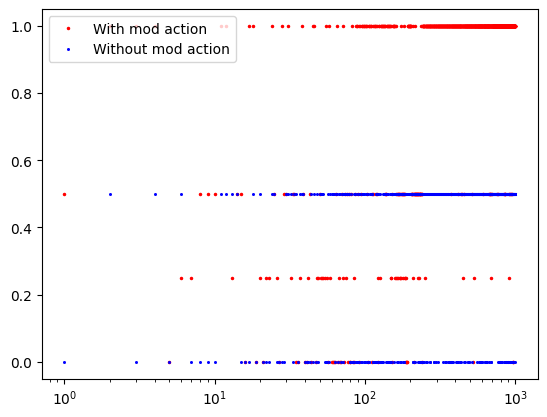

In [13]:
import matplotlib.pyplot as plt
plt.semilogx(episode_final_fidelities_w_mod_action, 'ro', markersize = 1.5, label = "With mod action")
plt.semilogx(episode_final_fidelities_wo_mod_action, 'bx', markersize = 1.5, label = "Without mod action")
plt.legend()